
<div style="border:1px solid #ccc; padding:15px; border-radius:10px; background-color:#f9f9f9">


<h1 style="color:black;">Simulering av utspädningskylare</h1>

<p style="color:#444;">
<b>Författare:</b> Martin Bornecrantz, Axel Skog Brönnestam, Hugo Engh, Melvin Ottosson, Magdalena Hansson, Oscar Mohlin Lindgren<br>
<b>Institution:</b> INSTITUTIONEN FÖR MEKANIK OCH MARITIMA VETENSKAPER, Chalmers Tekniska Högskola<br>
<b>Datum:</b> 2026-04-25<br>
<b>Version:</b> 3.2</p>

</div>

## Denna notebook används för att köra simuleringen av utspädningskylaren i `DR_OOP/`.

```
DR/
│
├── DR_sim.ipynb
│
├── DR_OOP/
│   ├── __init__.py
│   ├── komponenter.py
│   ├── konstanter.py
│   └── termiskdata.py
│
└── data/
    ├── H_losning.csv
    ├── H_rent_He3.csv
    ├── Xv.csv
    ├── pv.csv
    ├── kemisk_potential4.csv
    └── mu40_He4.csv
```

___

Simuleringen ligger till grund för en parameterstudie med syfte att identifiera optimala parametrar för maximal kyleffekt. 
Den används även för att undersöka begränsningar i skalbarheten hos en utspädningskylare.

Systemet har delats upp i flera delsystem (se figur 2) som definieras i filen `samband`, tillsammans med övriga fysikaliska relationer.

Mappen `data/` innehåller tabelldata från [Radebaugh](https://nvlpubs.nist.gov/nistpubs/Legacy/TN/nbstechnicalnote362.pdf).
___




### Figur 1: Översikt av systemet

![Illustration över hela systemet](System.png)





In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import copy

PROJECT_ROOT = Path().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from DR_OOP import (
    Blandningskammare,
    Destillator,
    Pump,
    Värmeväxlare,
    Fluid,
    TermiskData,
)
import DR_OOP.konstanter as konst


### Figur 2: Översikt av delsystemen
![Illustration över delsystemet](Delsystem.png)

### Figur 3: Översikt av segmentdelsystemen
![Illustration över segment-delsystemet](Segment.png)



In [2]:
# ============================================================
# PARAMETERSTUDIE
# ============================================================

def standard_parametrar():
    """
    Funktionen definierar standard parametrar. 
    Standrad parametrarna kommer från olika källor samt första iterationen av kod utvecklingen som fungerade
    
    """

    return dict(
       
        # Driftpunkt
        T_mc       = konst.T_mc,        # Blandningskammarens temperatur konstant [K]
        X_v_mål    = 0.75,              # Önskad He-3 molfraktion i ångfasen  [-]
        T_rum      = konst.T_rum,       # Rumstemperatur vid pumpen  [K]
        T_varm_in  = konst.T_varm_in,   # Temperatur in i värmeväxlaren från 1 K-pot  [K]

        # Still
        r_still    = 1.5e-3,            # Öppningsradie för utflöde vid stillen [m]

        # Värmeväxlare
        L_vvx      = 1,                 # Värmeväxlarlängd  [m]
        p_vvx      = konst.p,           # Ytarea per längdenhet

        # Pump
        #P_pump_ut  = 30 * 133.322,   # Pa ut ur pumpen (Radebaugh)
        P_pump_ut  = 30_000,   # Pa ut ur pumpen (Radebaugh)


        # Rörsegment
        # L: längden på röret [P_pump_utm], r: radien på röret [m], n: antal böjningar [-], T1: temperaturen in i röret [K], T2: Temperaturen ut ur röret [K], delta: geometrifaktor [-]
        rör = dict(
            seg1 = dict(L=0.5, r=0.01, n=0, T1=None,        T2=konst.T_rum, delta=0.1),  # T1=T_s, sätts dynamiskt
            seg2 = dict(L=1, r=0.005, n=3, T1=konst.T_rum, T2=50,          delta=0.1),
            seg3 = dict(L=1, r=0.003, n=0, T1=50,          T2=4.2,         delta=0.1),
            seg4 = dict(L=1, r=0.001, n=1, T1=4.2,         T2=1,           delta=0.1),
            seg5 = dict(L=5, r=0.001, n=10, T1=1,           T2=0.7,         delta=0.1), # detta rörsegment har flödesimpedansen i sig och där med är det många bends n, och en längre sträcka L
        )
    )



## Simuleringsflöde

Simuleringen genomförs sekventiellt enligt följande steg:

---

### 1. Initialisering

* Temperaturen i blandningskammaren sätts till ett konstant värde: `T_mc`
* Molfractionen i den utspädda fasen i blandningskammaren beräknas

---

### 2. Destillator

De beräknade värdena används som indata till destillatorn, vilket ger:

* Temperatur: `T_s`
* Molfraction i vätska: `X_s`
* Molfraction i gas: `X_v`
* Gastryck: `p_v`

Med de nya värdena erhålls:

* Molflöde: `m_prick`
* Tryck vid destillatorns utloppsmynning: `p_c`
* Molfraction genom systemet: `x_in`

---

### 3. Flöde genom systemet

* Tryckförändringar genom systemet beräknas
* Beräkningarna utförs med `fluid`-klassen från destillatorn till värmeväxlaren

---

### 4. Pumpkrav

* Den minsta pumphastigheten som krävs för att systemet ska cirkulera bestäms: `S_min`

---

### 5. Värmeväxlare

* Temperaturerna in i:

  * Blandningskammaren: `T_in_mc` 
  * Destillatorn: `T_in_still`
  
  beräknas utifrån värmeväxlaren

---

### 6. Resultat

* Kyleffekten från blandningskammaren beräknas: `Q_kyl`

---


In [3]:
def kör_varv(p):

    """
    Den funktion kör igenom hela systemet med insatta parametrar p för att få relevanta värden och 
    
    """

    #Skapar ett lokalt-alias för enklare användning
    seg = p["rör"]

 

    #Skapar klasser 
    dest = Destillator(r=p["r_still"])
    pump = Pump()
    bk   = Blandningskammare()
    vvx  = Värmeväxlare(L=p["L_vvx"], p=p["p_vvx"])


    #Skapar rörklasserna för de fem olika segmenten
    rör1 = Fluid(L=seg["seg1"]["L"], r=seg["seg1"]["r"], n=seg["seg1"]["n"], T_1=1,               T_2=seg["seg1"]["T2"])
    rör2 = Fluid(L=seg["seg2"]["L"], r=seg["seg2"]["r"], n=seg["seg2"]["n"], T_1=seg["seg2"]["T1"], T_2=seg["seg2"]["T2"])
    rör3 = Fluid(L=seg["seg3"]["L"], r=seg["seg3"]["r"], n=seg["seg3"]["n"], T_1=seg["seg3"]["T1"], T_2=seg["seg3"]["T2"])
    rör4 = Fluid(L=seg["seg4"]["L"], r=seg["seg4"]["r"], n=seg["seg4"]["n"], T_1=seg["seg4"]["T1"], T_2=seg["seg4"]["T2"])
    rör5 = Fluid(L=seg["seg5"]["L"], r=seg["seg5"]["r"], n=seg["seg5"]["n"], T_1=seg["seg5"]["T1"], T_2=seg["seg5"]["T2"])

    #kallar på blandningskammare temperaturen och molfraktionen i den utspädda delen    
    T_mc = p["T_mc"]
    X_mc = bk.x_mc(T_mc)

    # Räknar ut destillatorns temperatur, molfraktion i vätskan och i gasen samt ångtrycket
    T_s, X_s, X_v, p_v = dest.egenskaper(T_mc, X_mc, p["X_v_mål"])
    # Räknar ut Molflödet, trycket vid utloppsmynningen till destilatorn och molfractionen
    m_prick, Pc, X_in   = dest.molflöde(T_s, X_s, p_v, X_v)

    # Räknar ut Q_faktiskt som är flödet i [Watt] och nedströmstryck
    Q_faktiskt_1     = m_prick * T_s * konst.R
    p_ut_1 = rör1.P_get_BV_2(2, Pc, Q_faktiskt_1, T_s, seg["seg1"]["T2"],
                              seg["seg1"]["L"], seg["seg1"]["r"], seg["seg1"]["n"], seg["seg1"]["delta"])

    Q_faktiskt_2     = m_prick * seg["seg2"]["T1"] * konst.R
    p_ut_2 = rör2.P_get_BV_2(2, p["P_pump_ut"], Q_faktiskt_2, seg["seg2"]["T1"], seg["seg2"]["T2"],
                              seg["seg2"]["L"], seg["seg2"]["r"], seg["seg2"]["n"], seg["seg2"]["delta"])

    Q_faktiskt_3     = m_prick * seg["seg3"]["T1"] * konst.R
    p_ut_3 = rör3.P_get_BV_2(2, p_ut_2, Q_faktiskt_3, seg["seg3"]["T1"], seg["seg3"]["T2"],
                              seg["seg3"]["L"], seg["seg3"]["r"], seg["seg3"]["n"], seg["seg3"]["delta"])

    Q_faktiskt_4     = m_prick * seg["seg4"]["T1"] * konst.R
    p_ut_4 = rör4.P_get_BV_2(2, p_ut_3, Q_faktiskt_4, seg["seg4"]["T1"], seg["seg4"]["T2"],
                              seg["seg4"]["L"], seg["seg4"]["r"], seg["seg4"]["n"], seg["seg4"]["delta"])

    Q_faktiskt_5     = m_prick * seg["seg5"]["T1"] * konst.R
    p_ut_5 = rör5.P_get_BV_2(2, p_ut_4, Q_faktiskt_5, seg["seg5"]["T1"], seg["seg5"]["T2"],
                              seg["seg5"]["L"], seg["seg5"]["r"], seg["seg5"]["n"], seg["seg5"]["delta"])
    
    # Räknar ut minsta pumphastigheten som krävs för systemet
    S_min  = pump.s_pump_critical(p["T_rum"], p_ut_1, m_prick)

    # Räknar ut Temperaturen in i blandningskammaren och destilatorn från värmeväxlaren
    m_prick_vvx = 100e-6 

    antal_parralellkopplade_vvx = m_prick/m_prick_vvx

    T_in_mc, T_in_still = vvx.brent_VVX(T_mc, X_mc, m_prick_vvx, X_in, plotta=0)
    

    # Räknar ut kyleffekt i blandningskammaren
    Q_kyl = bk.Q_allmän(
        m_prick = m_prick,
        X_in    = X_in,
        T_mc    = T_mc,
        T_in    = T_in_mc,
    )

    
    return dict(
        T_mc       = T_mc,
        X_mc       = X_mc,
        T_s        = T_s,
        X_s        = X_s,
        X_v        = X_v,
        X_in       = X_in,
        p_v        = p_v,
        Pc         = Pc,
        m_prick    = m_prick,
        S_min      = S_min,
        p_ut_1     = p_ut_1,
        p_ut_2     = p_ut_2,
        p_ut_3     = p_ut_3,
        p_ut_4     = p_ut_4,
        p_ut_5     = p_ut_5,
        T_in_mc    = T_in_mc,
        T_in_still = T_in_still,
        Q_kyl      = Q_kyl,
        antal_parralellkopplade_vvx = antal_parralellkopplade_vvx
    )



# Resultat av standrad parametrar
___

In [4]:
bas = standard_parametrar()
res = kör_varv(bas)
print("=" * 45)
print(f"{'SIMULERINGSRESULTAT':^45}")
print("=" * 45)

print(f"\n{'--- Destillator & pump ---':}")
print(f"  T_s        = {res['T_s']:.4f}  K")
print(f"  X_s        = {res['X_s']:.4f}  -")
print(f"  X_v        = {res['X_v']:.4f}  -")
print(f"  X_in       = {res['X_in']:.4f}  -")
print(f"  p_v        = {res['p_v']:.2f}  Pa")
print(f"  Pc         = {res['Pc']:.2f}  Pa")

print(f"  m_prick    = {res['m_prick']:.3e}  mol/s")
print(f"  S_min      = {res['S_min']*1e3:.4f}  l/s")

print(f"\n{'--- Tryck ut per segment ---':}")
for i in range(1, 6):
    print(f"  p_ut_{i}     = {res[f'p_ut_{i}']:.2f}  Pa")

print(f"\n{'--- Värmeväxlare ---':}")
print(f"  T_in_mc    = {res['T_in_mc']:.4f}  K")
print(f"  T_in_still = {res['T_in_still']:.4f}  K")
print(f" antal_parralellkopplade_vvx = {res['antal_parralellkopplade_vvx']:.1f}")

print(f"\n{'--- Resultat ---':}")
print(f"  Q_kyl      = {res['Q_kyl']*1e6:.4f}  µW")



             SIMULERINGSRESULTAT             

--- Destillator & pump ---
  T_s        = 0.9465  K
  X_s        = 0.0076  -
  X_v        = 0.7500  -
  X_in       = 0.7477  -
  p_v        = 45.89  Pa
  Pc         = 22.35  Pa
  m_prick    = 1.333e-03  mol/s
  S_min      = 149.9113  l/s

--- Tryck ut per segment ---
  p_ut_1     = 22.17  Pa
  p_ut_2     = 29991.32  Pa
  p_ut_3     = 29990.49  Pa
  p_ut_4     = 29983.02  Pa
  p_ut_5     = 29968.59  Pa

--- Värmeväxlare ---
  T_in_mc    = 0.2196  K
  T_in_still = 0.1684  K
 antal_parralellkopplade_vvx = 13.3

--- Resultat ---
  Q_kyl      = 346.8301  µW


___
# Parameterstudie
___

In [5]:
def svep(parameter_namn, värden, bas=None):
    """Sveper över en parameter och returnerar en DataFrame med resultat."""
    if bas is None:
        bas = standard_parametrar()
    
    rader = []
    for v in värden:
        p = copy.deepcopy(bas)
        p[parameter_namn] = v
        try:
            res = kör_varv(p)
            rader.append({parameter_namn: v, **res})
            print(f"{parameter_namn}={v:.4f} OK | Q={res['Q_kyl']*1e6:.2f} µW")
        except Exception as e:
            print(f"{parameter_namn}={v:.4f} FAIL | {e}")
    
    return pd.DataFrame(rader)

In [6]:
df1 = svep("r_still",  np.linspace(0.001, 0.006, 50))
df2 = svep("T_mc",     np.linspace(0.07,  0.1,   50))
df3 = svep("X_v_mål",  np.linspace(0.50,  0.95,  50))

r_still=0.0010 OK | Q=154.00 µW
r_still=0.0011 OK | Q=187.08 µW
r_still=0.0012 OK | Q=223.38 µW
r_still=0.0013 OK | Q=262.89 µW
r_still=0.0014 OK | Q=305.62 µW
r_still=0.0015 OK | Q=351.57 µW
r_still=0.0016 OK | Q=400.73 µW
r_still=0.0017 OK | Q=453.11 µW
r_still=0.0018 OK | Q=508.71 µW
r_still=0.0019 OK | Q=567.52 µW
r_still=0.0020 OK | Q=629.55 µW
r_still=0.0021 OK | Q=694.80 µW
r_still=0.0022 OK | Q=763.26 µW
r_still=0.0023 OK | Q=834.94 µW
r_still=0.0024 OK | Q=909.83 µW
r_still=0.0025 OK | Q=987.94 µW
r_still=0.0026 OK | Q=1069.27 µW
r_still=0.0027 OK | Q=1153.81 µW
r_still=0.0028 OK | Q=1241.57 µW
r_still=0.0029 OK | Q=1332.55 µW
r_still=0.0030 OK | Q=1426.74 µW
r_still=0.0031 OK | Q=1524.15 µW
r_still=0.0032 OK | Q=1624.78 µW
r_still=0.0033 OK | Q=1728.62 µW
r_still=0.0034 OK | Q=1835.67 µW
r_still=0.0036 OK | Q=1945.95 µW
r_still=0.0037 OK | Q=2059.44 µW
r_still=0.0038 OK | Q=2176.15 µW
r_still=0.0039 OK | Q=2296.07 µW
r_still=0.0040 OK | Q=2419.21 µW
r_still=0.0041 OK | Q=2545

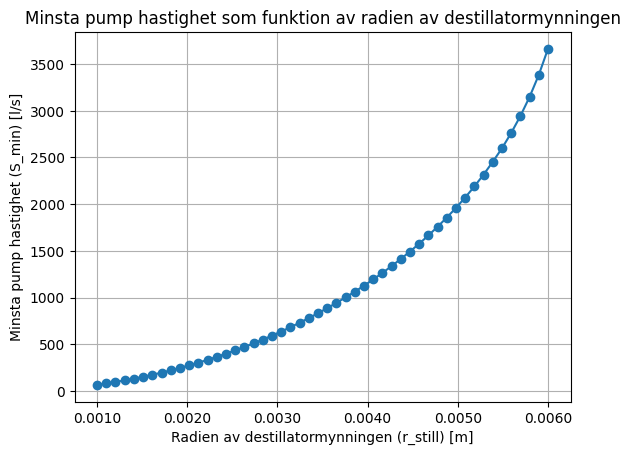

In [7]:
plt.figure()
plt.plot(df1["r_still"], df1["S_min"]*1e3 , marker='o')
plt.xlabel("Radien av destillatormynningen (r_still) [m]")
plt.ylabel("Minsta pump hastighet (S_min) [l/s]")
plt.title("Minsta pump hastighet som funktion av radien av destillatormynningen")

plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

plt.grid(True)
plt.show()

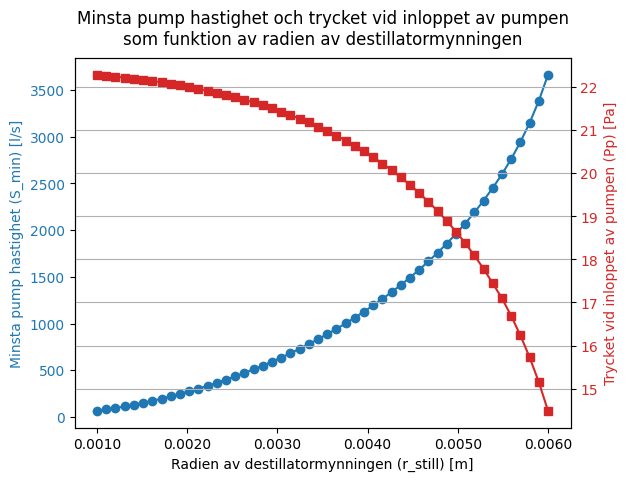

In [8]:
fig, ax1 = plt.subplots()

ax1.plot(df1["r_still"], df1["S_min"]*1e3, marker='o', color='tab:blue', label="S_min")
ax1.set_xlabel("Radien av destillatormynningen (r_still) [m]")
ax1.set_ylabel("Minsta pump hastighet (S_min) [l/s]", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

ax2 = ax1.twinx()  # delar x-axeln
ax2.plot(df1["r_still"], df1["p_ut_1"], marker='s', color='tab:red', label="Annat")
ax2.set_ylabel("Trycket vid inloppet av pumpen (Pp) [Pa]", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.set_title(
    "Minsta pump hastighet och trycket vid inloppet av pumpen\nsom funktion av radien av destillatormynningen",
    pad=10)
plt.grid(True)
plt.show()

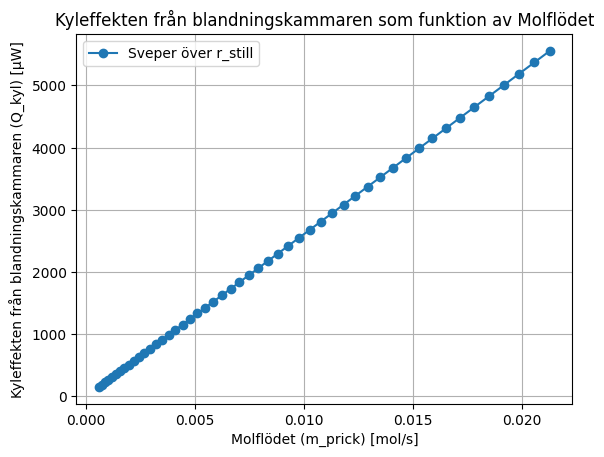

In [9]:
plt.figure()
plt.plot(df1["m_prick"], df1["Q_kyl"]*1e6 , marker='o', label="Sveper över r_still")
plt.xlabel("Molflödet (m_prick) [mol/s]")
plt.ylabel("Kyleffekten från blandningskammaren (Q_kyl) [µW]")
plt.title("Kyleffekten från blandningskammaren som funktion av Molflödet")
plt.legend()
plt.grid(True)
plt.show()

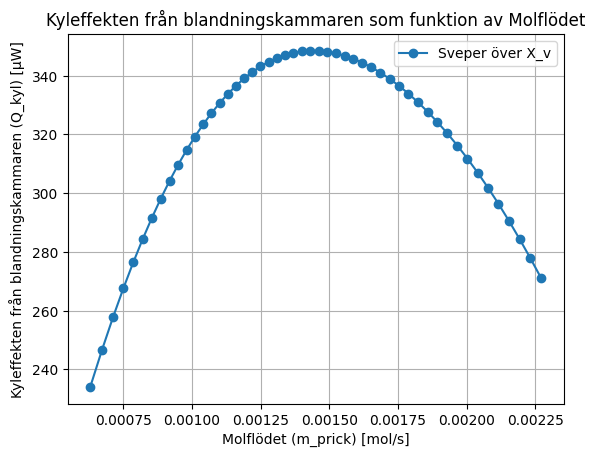

In [10]:
plt.figure()
plt.plot(df3["m_prick"], df3["Q_kyl"]*1e6 , marker='o', label="Sveper över X_v")
plt.xlabel("Molflödet (m_prick) [mol/s]")
plt.ylabel("Kyleffekten från blandningskammaren (Q_kyl) [µW]")
plt.title("Kyleffekten från blandningskammaren som funktion av Molflödet")
plt.legend()
plt.grid(True)
plt.show()

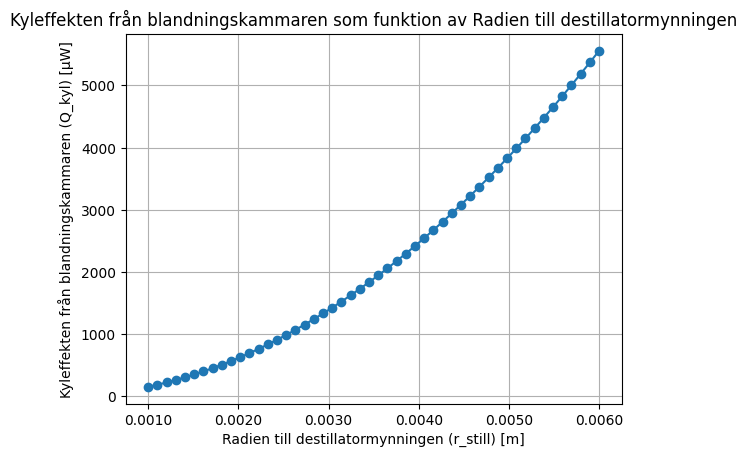

In [11]:
plt.figure()
plt.plot(df1["r_still"], df1["Q_kyl"] * 1e6, marker='o')
plt.xlabel("Radien till destillatormynningen (r_still) [m]")
plt.ylabel("Kyleffekten från blandningskammaren (Q_kyl) [µW]")
plt.title("Kyleffekten från blandningskammaren som funktion av Radien till destillatormynningen")
plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))
plt.grid(True)
plt.show()

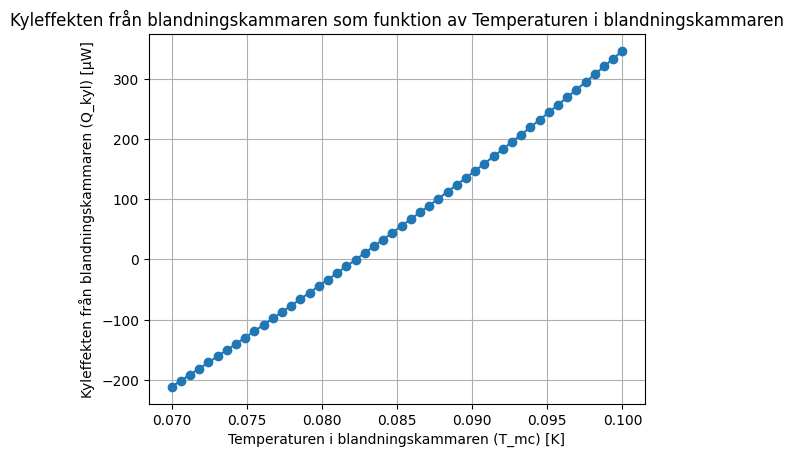

In [12]:
plt.figure()
plt.plot(df2["T_mc"], df2["Q_kyl"] * 1e6, marker='o')
plt.xlabel("Temperaturen i blandningskammaren (T_mc) [K]")
plt.ylabel("Kyleffekten från blandningskammaren (Q_kyl) [µW]")
plt.title("Kyleffekten från blandningskammaren som funktion av Temperaturen i blandningskammaren")
plt.grid(True)
plt.show()

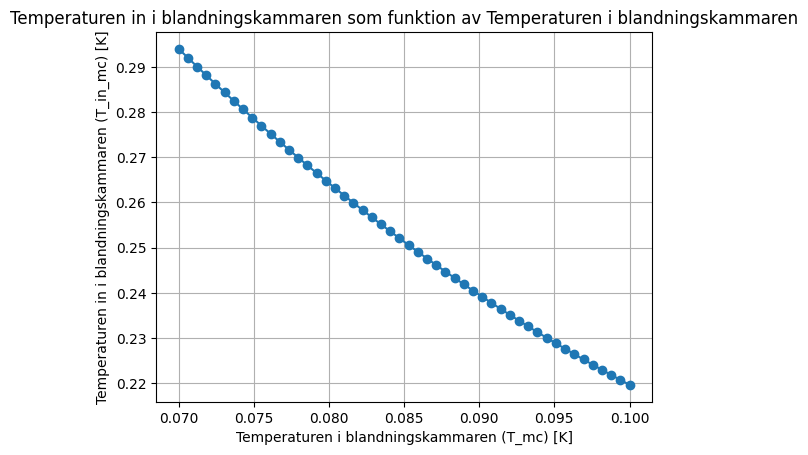

In [13]:
plt.figure()
plt.plot(df2["T_mc"], df2["T_in_mc"] , marker='o')
plt.xlabel("Temperaturen i blandningskammaren (T_mc) [K]")
plt.ylabel("Temperaturen in i blandningskammaren (T_in_mc) [K]")
plt.title("Temperaturen in i blandningskammaren som funktion av Temperaturen i blandningskammaren")
plt.grid(True)
plt.show()

In [14]:
k, m = np.polyfit(df2["T_mc"], df2["T_in_mc"], 1)

print(f"k = {k:.4f}")
print(f"m = {m:.4f}")
print(f"Ekvation: y = {k:.4f}x + {m:.4f}")

def vvx_regression(T_mc):
    return -2.4740 * T_mc + 0.4635

k = -2.4740
m = 0.4635
Ekvation: y = -2.4740x + 0.4635


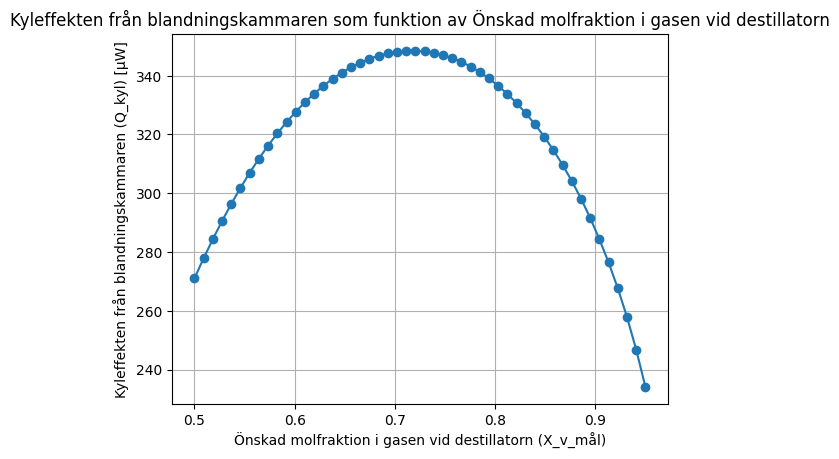

In [15]:
plt.figure()
plt.plot(df3["X_v_mål"], df3["Q_kyl"] * 1e6, marker='o')
plt.xlabel("Önskad molfraktion i gasen vid destillatorn (X_v_mål)")
plt.ylabel("Kyleffekten från blandningskammaren (Q_kyl) [µW]")
plt.title("Kyleffekten från blandningskammaren som funktion av Önskad molfraktion i gasen vid destillatorn")
plt.grid(True)
plt.show()

## Källor

1. Zu, H., Dai, W. & de Waele, A. T. A. M. (2022). Development of dilution refrigerators—A review. 
   *Cryogenics*, 121. Elsevier Ltd. https://doi.org/10.1016/j.cryogenics.2021.103390

2. Wheatley, J. C. (1968). Dilute Solutions of He3 in He4 at Low Temperatures. 
   *American Journal of Physics*, 36(3), 181–210. https://doi.org/10.1119/1.1974483

3. Wikus, P. & Weber, H. (u.å.). *Dilution Refrigeration of Multi-Ton Cold Masses* 
   [Doktorsavhandling, Technische Universität Wien]. http://www.ub.tuwien.ac.at

4. Pradhan, J., Das, N. K. & Chakraborty, A. (2013). Thermo-dynamical process simulation of 
   dilution refrigerator. *Cryogenics*, 57, 158–165. https://doi.org/10.1016/j.cryogenics.2013.07.003

5. Radebaugh, R. (1967). *Thermodynamic properties of He3-He4 solutions with applications to 
   the He3-He4 dilution refrigerator* (NBS Technical Note 362). National Bureau of Standards. 
   https://doi.org/10.6028/NBS.TN.362